# SalesFlow Analytics — Visual EDA Completed

Готовая версия EDA с KPI, графиками и сохранением изображений для PPT.

Clean Sales Dataset Loaded
Shape: (108552, 15)


,SalesOrderLineKey,ResellerKey,CustomerKey,ProductKey,OrderDateKey,DueDateKey,ShipDateKey,SalesTerritoryKey,Order Quantity,Unit Price,Extended Amount,Unit Price Discount Pct,Product Standard Cost,Total Product Cost,Sales Amount
0,43659001,676,0,113,20170702,20170712,20170709.0,4,1,2024.994,2024.994,0,1898.0944,1898.0944,2024.994
1,43659003,676,0,115,20170702,20170712,20170709.0,4,1,2024.994,2024.994,0,1898.0944,1898.0944,2024.994
2,43659004,676,0,108,20170702,20170712,20170709.0,4,1,2039.994,2039.994,0,1912.1544,1912.1544,2039.994
3,43659005,676,0,109,20170702,20170712,20170709.0,4,1,2039.994,2039.994,0,1912.1544,1912.1544,2039.994
4,43659007,676,0,111,20170702,20170712,20170709.0,4,1,2039.994,2039.994,0,1912.1544,1912.1544,2039.994



KPI Overview
Total Revenue: $54,550,637.84
Orders / Sales Lines: 108,552
Average Sales Amount: $502.53
Unique Products: 350
Unique Customers: 17,972


,KPI,Value
0,Total Revenue,5.455064e+07
1,Orders / Sales Lines,1.085520e+05
2,Average Sales Amount,5.025300e+02
3,Unique Products,3.500000e+02
4,Unique Customers,1.797200e+04


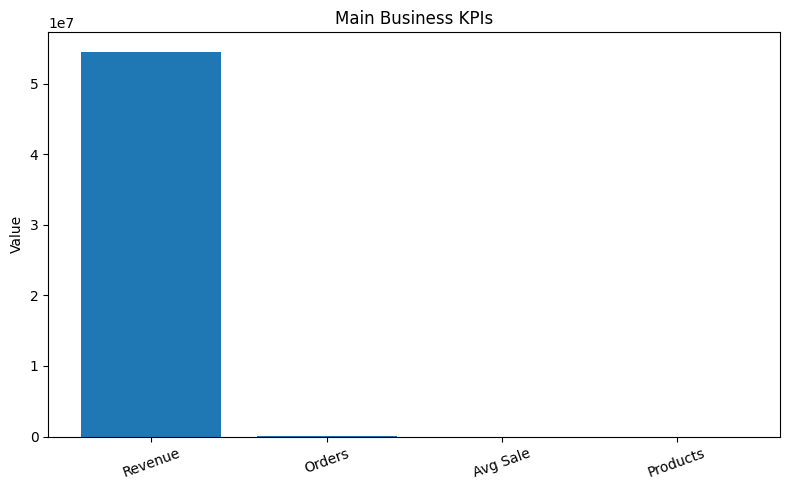

,SalesTerritoryKey,Sales Amount
3,3,1.147195e+07
5,5,7.531290e+06
8,8,7.350841e+06
0,0,6.875268e+06
9,9,4.626132e+06
6,6,3.990506e+06
7,7,3.209830e+06
4,4,3.209525e+06
1,1,3.158600e+06
2,2,3.126691e+06


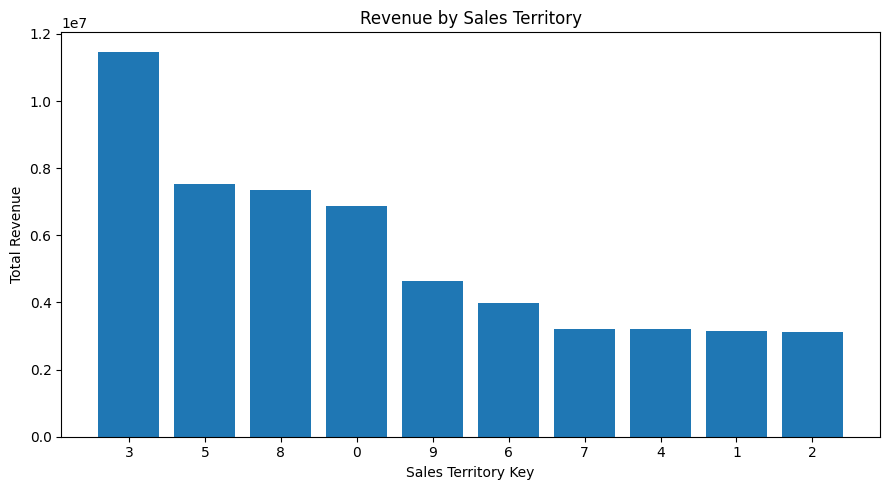

,ProductKey,Sales Amount
123,123,1.259032e+06
125,125,1.198903e+06
127,127,1.159888e+06
117,117,1.022188e+06
121,121,9.790358e+05
119,119,9.553719e+05
124,124,6.450561e+05
324,324,6.133770e+05
122,122,6.130902e+05
120,120,6.081688e+05


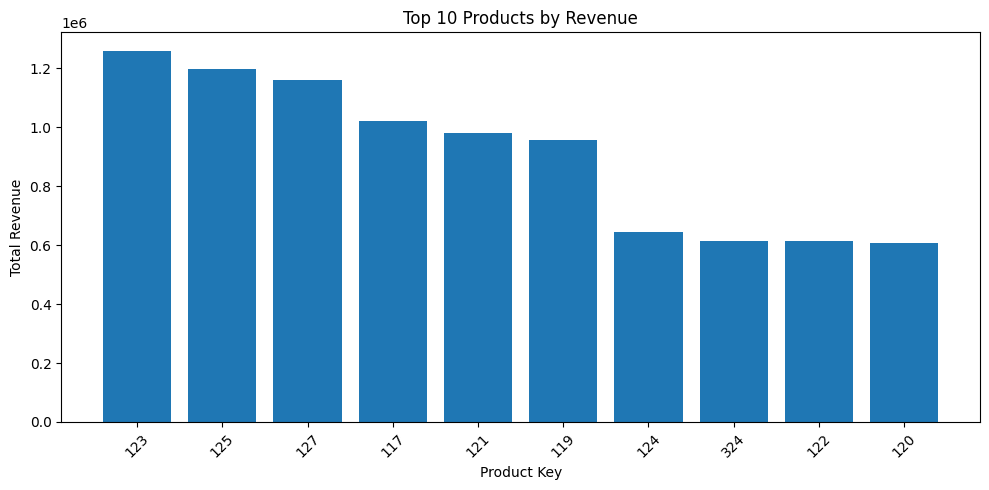

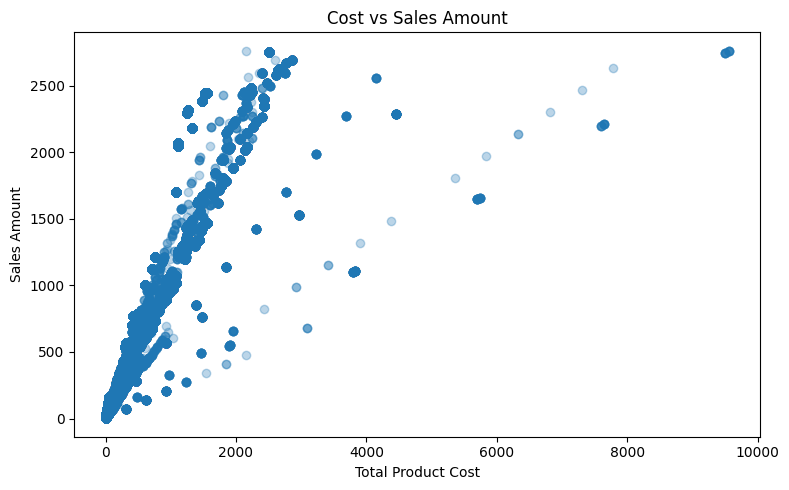

Correlation between Total Product Cost and Sales Amount: 0.9221


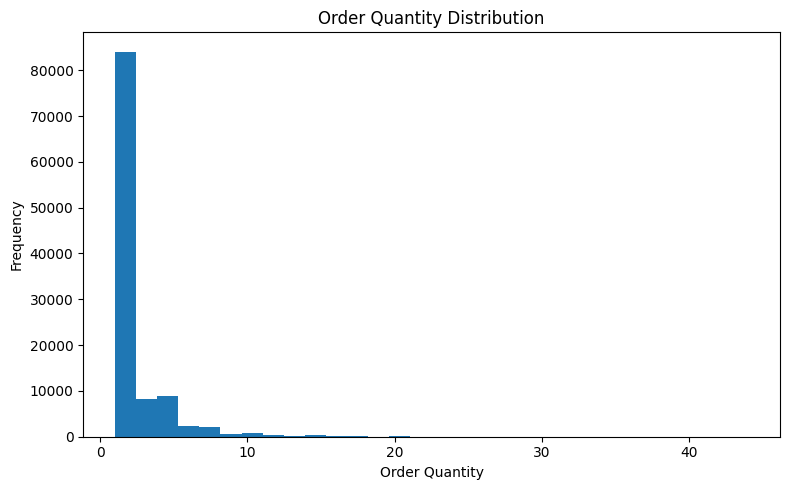

count    108552.000000
mean          2.083370
std           2.376768
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          44.000000
Name: Order Quantity, dtype: float64

,CustomerKey,Purchase_Count,Total_Revenue,Average_Purchase
0,0,51121,3.210703e+07,628.059579
434,434,12,1.290967e+04,1075.805683
440,440,14,1.248917e+04,892.083543
242,242,25,1.146919e+04,458.767528
418,418,17,1.124846e+04,661.674012
421,421,17,1.120077e+04,658.868800
243,243,12,1.106801e+04,922.334017
426,426,15,1.052863e+04,701.908547
430,430,17,1.046838e+04,615.787035
3165,3165,10,9.796320e+03,979.632000


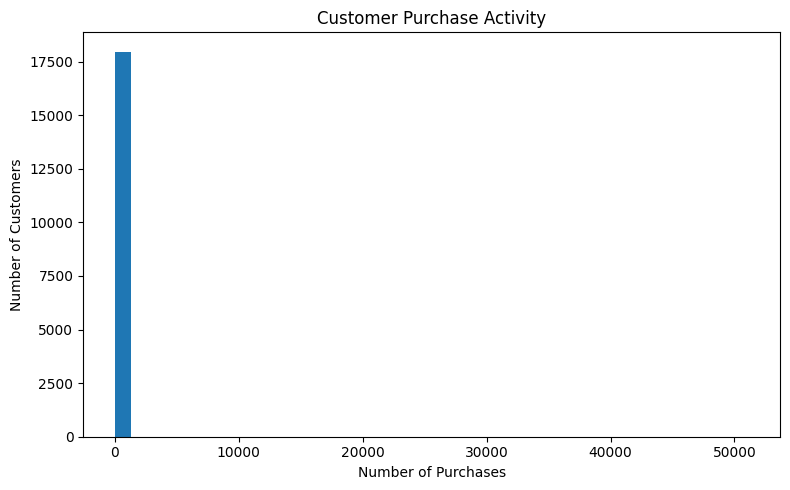

,YearMonth,Sales Amount
0,2017-07,2.533160e+05
1,2017-08,4.935913e+05
2,2017-09,6.895322e+05
3,2017-10,1.328287e+04
4,2017-11,1.207281e+06


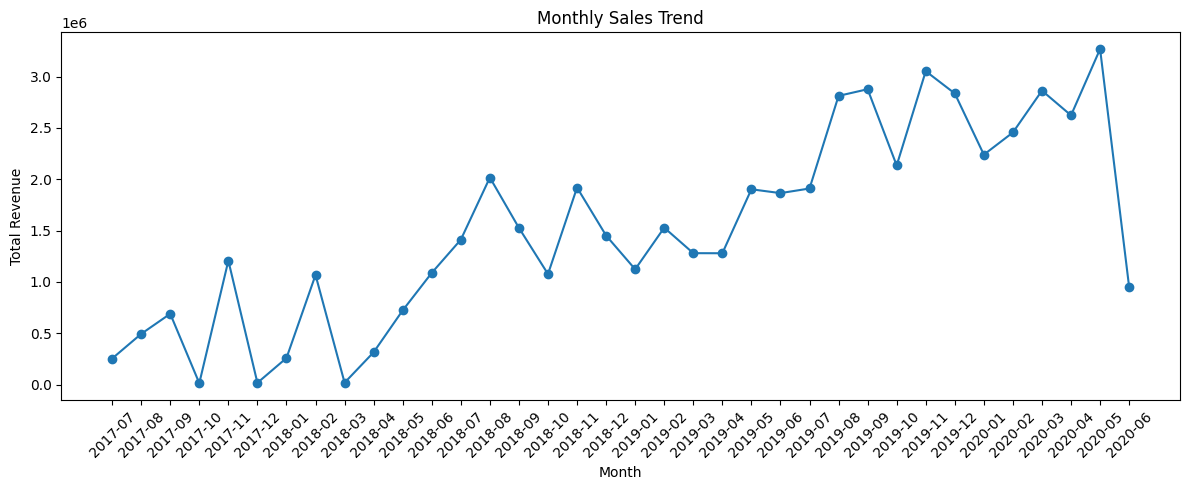


Final EDA Insights

1. Total revenue is $54,550,637.84, showing strong business scale.

2. The dataset contains 108,552 sales lines and 17,972 unique customers.

3. Revenue is not evenly distributed across territories.
   Some territories generate significantly higher sales than others.

4. The top 10 products make a large contribution to total revenue.
   This is useful for CRM campaigns and inventory planning.

5. Cost and sales amount have a strong business relationship.
   Correlation: 0.9221

6. Customer purchase activity is uneven.
   Some customers buy repeatedly, while many customers have fewer transactions.

7. These results can support:
   - sales forecasting
   - customer segmentation
   - product recommendation
   - territory performance analysis
   - CRM strategy improvement



In [1]:

# ============================================================
# SalesFlow Analytics
# 03 Visual EDA - Completed Version
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------------------
# Load clean dataset
# ------------------------------------------------------------
DATA_PATH = "clean_sales_data.csv"

if not os.path.exists(DATA_PATH):
    # Works when running from another folder
    DATA_PATH = r"/mnt/data/clean_sales_data.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("Clean Sales Dataset Loaded")
print("=" * 60)
print("Shape:", df.shape)
display(df.head())

# ------------------------------------------------------------
# Create output folder for PPT charts
# ------------------------------------------------------------
CHART_DIR = "charts_eda"
os.makedirs(CHART_DIR, exist_ok=True)

# ------------------------------------------------------------
# Basic date features
# ------------------------------------------------------------
if "OrderDateKey" in df.columns:
    df["OrderDateKey"] = df["OrderDateKey"].astype(str)
    df["OrderDate"] = pd.to_datetime(df["OrderDateKey"], format="%Y%m%d", errors="coerce")
    df["Year"] = df["OrderDate"].dt.year
    df["Month"] = df["OrderDate"].dt.month
    df["YearMonth"] = df["OrderDate"].dt.to_period("M").astype(str)

# ------------------------------------------------------------
# KPI Overview
# ------------------------------------------------------------
total_revenue = df["Sales Amount"].sum()
orders = df["SalesOrderLineKey"].nunique() if "SalesOrderLineKey" in df.columns else len(df)
avg_sales = df["Sales Amount"].mean()
products = df["ProductKey"].nunique() if "ProductKey" in df.columns else None
customers = df["CustomerKey"].nunique() if "CustomerKey" in df.columns else None

print("\n" + "=" * 60)
print("KPI Overview")
print("=" * 60)
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Orders / Sales Lines: {orders:,}")
print(f"Average Sales Amount: ${avg_sales:,.2f}")
print(f"Unique Products: {products:,}")
print(f"Unique Customers: {customers:,}")

kpi_df = pd.DataFrame({
    "KPI": ["Total Revenue", "Orders / Sales Lines", "Average Sales Amount", "Unique Products", "Unique Customers"],
    "Value": [total_revenue, orders, avg_sales, products, customers]
})

display(kpi_df)

# KPI chart
plt.figure(figsize=(8, 5))
plt.bar(["Revenue", "Orders", "Avg Sale", "Products"], [total_revenue, orders, avg_sales, products])
plt.title("Main Business KPIs")
plt.ylabel("Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "01_kpi_overview.png"), dpi=200)
plt.show()

# ------------------------------------------------------------
# Revenue by Territory
# ------------------------------------------------------------
territory_revenue = (
    df.groupby("SalesTerritoryKey", as_index=False)["Sales Amount"]
    .sum()
    .sort_values("Sales Amount", ascending=False)
)

display(territory_revenue)

plt.figure(figsize=(9, 5))
plt.bar(territory_revenue["SalesTerritoryKey"].astype(str), territory_revenue["Sales Amount"])
plt.title("Revenue by Sales Territory")
plt.xlabel("Sales Territory Key")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "02_revenue_by_territory.png"), dpi=200)
plt.show()

# ------------------------------------------------------------
# Top 10 Products by Revenue
# ------------------------------------------------------------
top_products = (
    df.groupby("ProductKey", as_index=False)["Sales Amount"]
    .sum()
    .sort_values("Sales Amount", ascending=False)
    .head(10)
)

display(top_products)

plt.figure(figsize=(10, 5))
plt.bar(top_products["ProductKey"].astype(str), top_products["Sales Amount"])
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Key")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "03_top_10_products.png"), dpi=200)
plt.show()

# ------------------------------------------------------------
# Cost vs Sales Amount
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(df["Total Product Cost"], df["Sales Amount"], alpha=0.3)
plt.title("Cost vs Sales Amount")
plt.xlabel("Total Product Cost")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "04_cost_vs_sales.png"), dpi=200)
plt.show()

correlation = df[["Total Product Cost", "Sales Amount"]].corr().iloc[0, 1]
print(f"Correlation between Total Product Cost and Sales Amount: {correlation:.4f}")

# ------------------------------------------------------------
# Order Quantity Distribution
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(df["Order Quantity"], bins=30)
plt.title("Order Quantity Distribution")
plt.xlabel("Order Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "05_order_quantity_distribution.png"), dpi=200)
plt.show()

quantity_summary = df["Order Quantity"].describe()
display(quantity_summary)

# ------------------------------------------------------------
# Customer Purchase Activity
# ------------------------------------------------------------
customer_activity = (
    df.groupby("CustomerKey", as_index=False)
    .agg(
        Purchase_Count=("SalesOrderLineKey", "count"),
        Total_Revenue=("Sales Amount", "sum"),
        Average_Purchase=("Sales Amount", "mean")
    )
    .sort_values("Total_Revenue", ascending=False)
)

display(customer_activity.head(10))

plt.figure(figsize=(8, 5))
plt.hist(customer_activity["Purchase_Count"], bins=40)
plt.title("Customer Purchase Activity")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "06_customer_purchase_activity.png"), dpi=200)
plt.show()

# ------------------------------------------------------------
# Bonus: Monthly Sales Trend
# Useful for PPT timeline slide
# ------------------------------------------------------------
if "YearMonth" in df.columns:
    monthly_sales = (
        df.groupby("YearMonth", as_index=False)["Sales Amount"]
        .sum()
        .sort_values("YearMonth")
    )

    display(monthly_sales.head())

    plt.figure(figsize=(12, 5))
    plt.plot(monthly_sales["YearMonth"], monthly_sales["Sales Amount"], marker="o")
    plt.title("Monthly Sales Trend")
    plt.xlabel("Month")
    plt.ylabel("Total Revenue")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(CHART_DIR, "07_monthly_sales_trend.png"), dpi=200)
    plt.show()

# ------------------------------------------------------------
# Final EDA Insights
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("Final EDA Insights")
print("=" * 60)

print(f"""
1. Total revenue is ${total_revenue:,.2f}, showing strong business scale.

2. The dataset contains {orders:,} sales lines and {customers:,} unique customers.

3. Revenue is not evenly distributed across territories.
   Some territories generate significantly higher sales than others.

4. The top 10 products make a large contribution to total revenue.
   This is useful for CRM campaigns and inventory planning.

5. Cost and sales amount have a strong business relationship.
   Correlation: {correlation:.4f}

6. Customer purchase activity is uneven.
   Some customers buy repeatedly, while many customers have fewer transactions.

7. These results can support:
   - sales forecasting
   - customer segmentation
   - product recommendation
   - territory performance analysis
   - CRM strategy improvement
""")
